In [2]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam



2024-11-10 21:32:19.306840: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-10 21:32:20.086784: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2024-11-10 21:33:01.639443: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-10 21:33:01.661858: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-10 21:33:01.662100: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [5]:
data_directory = './all_outputs/output_holistic_pickle/'
meta_data_file = './WLASL_v0.3.json'

In [6]:
content = json.load(open(meta_data_file))
filenames = set(os.listdir(data_directory))

In [7]:
# Shape of dataset (videos, frames, landmarks_fflattened)
# Number of videos = number of files in data_directory
# We take 24 frames from each video
# 

all_data = []

In [8]:
with open(data_directory + "28204.pkl", 'rb') as f:
        land_marks = pickle.load(f)
        # print the format of read data
        print(land_marks[0].keys())
        print(len(land_marks[40]['left_hand_landmarks']))

dict_keys(['pose_landmarks', 'face_landmarks', 'left_hand_landmarks', 'right_hand_landmarks'])
21


In [9]:
# Define indices for points of interest
pose_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24]
hand_indices = [0, 1, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [10]:

def load_landmarks(content, filenames, data_directory, num_frames):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for entry in content:
        instances = entry['instances']
        gloss = entry['gloss']  # label for current video

        for inst in instances:
            file_id = inst['video_id']
            if file_id + '.pkl' in filenames:
                with open(os.path.join(data_directory, file_id + '.pkl'), 'rb') as f:
                    landmarks = pickle.load(f)
                    
                    # Prepare frame storage for each video with fixed number of frames
                    frames = []

                    # Get frame sampling step (skip frames if necessary)
                    total_frames = len(landmarks)
                    step = max(1, total_frames // num_frames)
                    
                    # Process frames
                    for i in range(num_frames):
                        frame_index = i * step if total_frames >= num_frames else i
                        
                        if frame_index < total_frames:
                            frame = landmarks[frame_index]
                        else:
                            frame = None
                        
                        # Extract and flatten required points
                        pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                        left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                        right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                        # Collect only specified indices and flatten them
                        extracted_points = []

                        # Collect pose points first
                        for idx in pose_indices:
                            point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])
                        
                        # print(left_hand_points)
                        for idx in hand_indices:
                            point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])

                        # Collect right hand points
                        for idx in hand_indices:
                            point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])
                        
                        frames.append(extracted_points)
                    
                    # Add the processed video frames to the main array
                    video_data.append(frames)
                    labels.append(gloss)

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(content, filenames, data_directory, num_frames)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [11]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

19

In [12]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_one_hot = to_categorical(labels_encoded, num_classes=NUM_CLASSES)

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data, labels_one_hot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



In [13]:
# print train, val, test shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(95, 30, 66) (95, 19)
(21, 30, 66) (21, 19)
(21, 30, 66) (21, 19)


In [ ]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [ ]:
# Parameters
LSTM_HIDDEN_DIM = 256

# Model Definition
model = Sequential([
    # Dropout Layer for regularization
    Dropout(0.2, input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)),
    
    # Batch Normalization
    BatchNormalization(),
    
    # Two layers of BiLSTM with hidden dimension 256
    Bidirectional(LSTM(LSTM_HIDDEN_DIM, return_sequences=True)),
    Bidirectional(LSTM(LSTM_HIDDEN_DIM, return_sequences=True)),
    
    # Global Max Pooling to get a single vector representation
    GlobalMaxPooling1D(),
    
    # Output Layer with Softmax for classification
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the Model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print Model Summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 30, 66)            0         
                                                                 
 batch_normalization_1 (Bat  (None, 30, 66)            264       
 chNormalization)                                                
                                                                 
 bidirectional_2 (Bidirecti  (None, 30, 512)           661504    
 onal)                                                           
                                                                 
 bidirectional_3 (Bidirecti  (None, 30, 512)           1574912   
 onal)                                                           
                                                                 
 global_max_pooling1d_1 (Gl  (None, 512)               0         
 obalMaxPooling1D)                                    

In [17]:
# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=150, batch_size=32)


# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")




# Save label encoder and model if needed
# joblib.dump(label_encoder, 'label_encoder.pkl')
# model.save('lstm_landmark_model.h5')

Epoch 1/150


2024-11-10 21:34:12.790434: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2024-11-10 21:34:12.853606: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f7ab008e650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-10 21:34:12.853630: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2024-11-10 21:34:12.857674: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-10 21:34:12.979563: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 [==============================] - 6s 716ms/step - loss: 2.8999 - accuracy: 0.0737 - val_loss: 2.7556 - val_accuracy: 0.0476
Epoch 2/150
3/3 [==============================] - 0s 38ms/step - loss: 2.3708 - accuracy: 0.2421 - val_loss: 2.7220 - val_accuracy: 0.0952
Epoch 3/150
3/3 [==============================] - 0s 31ms/step - loss: 2.0890 - accuracy: 0.3368 - val_loss: 2.7179 - val_accuracy: 0.0476
Epoch 4/150
3/3 [==============================] - 0s 29ms/step - loss: 1.8743 - accuracy: 0.4632 - val_loss: 2.7703 - val_accuracy: 0.1429
Epoch 5/150
3/3 [==============================] - 0s 28ms/step - loss: 1.7156 - accuracy: 0.4737 - val_loss: 2.7939 - val_accuracy: 0.1429
Epoch 6/150
3/3 [==============================] - 0s 28ms/step - loss: 1.5228 - accuracy: 0.5474 - val_loss: 2.8962 - val_accuracy: 0.1429
Epoch 7/150
3/3 [==============================] - 0s 35ms/step - loss: 1.3705 - accuracy: 0.5789 - val_loss: 3.1464 - val_accuracy: 0.0952
Epoch 8/150
3/3 [==============

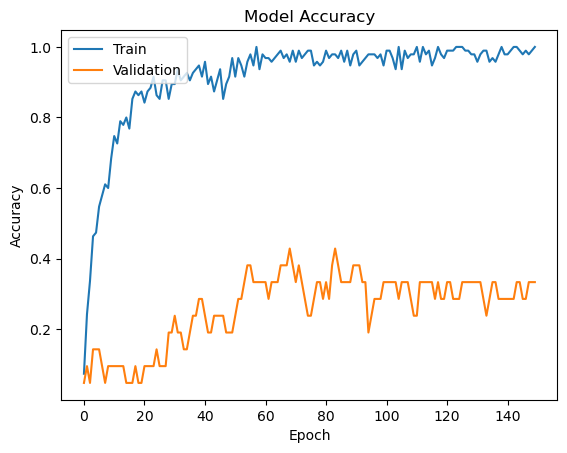

In [27]:

# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()



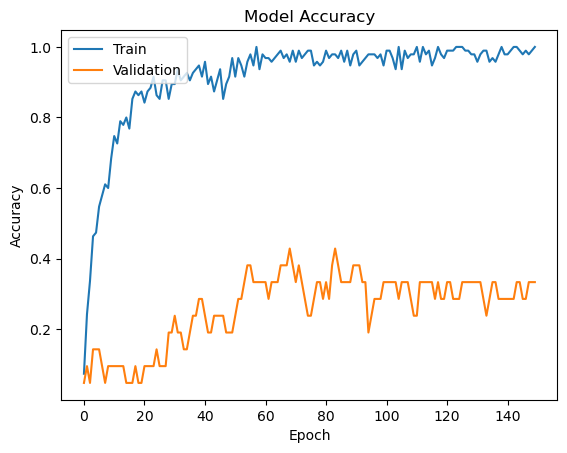

In [30]:
exp_number = 1
description = "Experiment with WLASL dataset with some classes that are also aviable in SSL datasets. About 19 classes and 137 videos"

# create folder to store results and store results if folder is already there, show error
if not os.path.exists('Results/exp_' + str(exp_number)):
    os.makedirs('Results/exp_' + str(exp_number))

    with open('Results/exp_' + str(exp_number) + '/description.txt', 'w') as f:
        f.write(description)

    # also save plots
        plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig('Results/exp_' + str(exp_number) + '/accuracy.png')


else:
    print("Folder already exists")


In [ ]:

# Define model parameters
input_dim = 512  # Adjust this based on your input feature size
hidden_dim = 256
output_dim = 10  # Adjust this based on the number of sign language classes

# Define the model architecture
class SignLanguageModel(tf.keras.Model):
    def __init__(self):
        super(SignLanguageModel, self).__init__()
        
        # Batch normalization layer
        self.batch_norm = tf.keras.layers.BatchNormalization()
        
        # Projection to lower dimension
        self.projection_layer = tf.keras.layers.Dense(input_dim, activation='relu')
        
        # Dropout layer
        self.dropout = tf.keras.layers.Dropout(0.2)
        
        # Two-layer BiLSTM
        self.bi_lstm1 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hidden_dim, return_sequences=True))
        self.bi_lstm2 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hidden_dim, return_sequences=True))
        
        # Max pooling layer
        self.max_pooling = tf.keras.layers.GlobalMaxPooling1D()
        
        # Output linear layer
        self.output_layer = tf.keras.layers.Dense(output_dim)
        
        # Softmax for classification
        self.softmax = tf.keras.layers.Softmax()

    def call(self, inputs, training=False):
        # Normalize inputs
        x = self.batch_norm(inputs, training=training)
        
        # Project to lower dimension
        x = self.projection_layer(x)
        
        # Apply dropout
        x = self.dropout(x, training=training)
        
        # BiLSTM layers
        x = self.bi_lstm1(x)
        x = self.bi_lstm2(x)
        
        # Max pooling
        x = self.max_pooling(x)
        
        # Final linear layer and softmax
        x = self.output_layer(x)
        x = self.softmax(x)
        
        return x

# Instantiate the model
model = SignLanguageModel()

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Example usage: Assuming `train_dataset` is a tf.data.Dataset containing (features, labels)
# model.fit(train_dataset, epochs=10, batch_size=512)
